<a href="https://colab.research.google.com/github/andreelzs/Linguagens-de-programacao/blob/main/analise_vendas_visual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercício Prático: Análise Visual de Vendas com Pandas e Matplotlib

## Bloco 1: Preparação do Ambiente e Dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
datas = pd.date_range(start="2024-01-01", end="2024-06-30", freq="D")
produtos = ["Notebook", "Smartphone", "Fone de Ouvido", "Monitor"]

dados = {
    "Data": np.random.choice(datas, size=300),
    "Produto": np.random.choice(produtos, size=300, p=[0.2, 0.4, 0.25, 0.15]),
    "Quantidade": np.random.randint(1, 6, size=300),
    "Preco_Unitario": 0
}

df = pd.DataFrame(dados)

precos = {"Notebook": 3500, "Smartphone": 2000, "Fone de Ouvido": 150, "Monitor": 1200}
df["Preco_Unitario"] = df["Produto"].map(precos)

print("Dataset criado com sucesso! Primeiras linhas:")
print(df.head(10))
print(f"\nTotal de registros: {len(df)}")

Dataset criado com sucesso! Primeiras linhas:
        Data         Produto  Quantidade  Preco_Unitario
0 2024-04-12         Monitor           3            1200
1 2024-06-28      Smartphone           1            2000
2 2024-04-02         Monitor           5            1200
3 2024-01-15  Fone de Ouvido           4             150
4 2024-04-16  Fone de Ouvido           1             150
5 2024-03-12      Smartphone           5            2000
6 2024-01-21      Smartphone           5            2000
7 2024-04-12      Smartphone           3            2000
8 2024-05-01        Notebook           5            3500
9 2024-03-15  Fone de Ouvido           5             150

Total de registros: 300


## Tarefa 1: Faturamento por Produto

In [2]:
df['Faturamento_Total'] = df['Quantidade'] * df['Preco_Unitario']

print("Coluna Faturamento_Total criada!")
print(df.head())

Coluna Faturamento_Total criada!
        Data         Produto  Quantidade  Preco_Unitario  Faturamento_Total
0 2024-04-12         Monitor           3            1200               3600
1 2024-06-28      Smartphone           1            2000               2000
2 2024-04-02         Monitor           5            1200               6000
3 2024-01-15  Fone de Ouvido           4             150                600
4 2024-04-16  Fone de Ouvido           1             150                150


In [3]:
faturamento_por_produto = df.groupby('Produto')['Faturamento_Total'].sum().sort_values(ascending=False)

print("Faturamento Total por Produto:")
print(faturamento_por_produto)
print(f"\nFaturamento Total Geral: R$ {faturamento_por_produto.sum():,.2f}")

Faturamento Total por Produto:
Produto
Notebook          686000
Smartphone        626000
Monitor           213600
Fone de Ouvido     30150
Name: Faturamento_Total, dtype: int64

Faturamento Total Geral: R$ 1,555,750.00


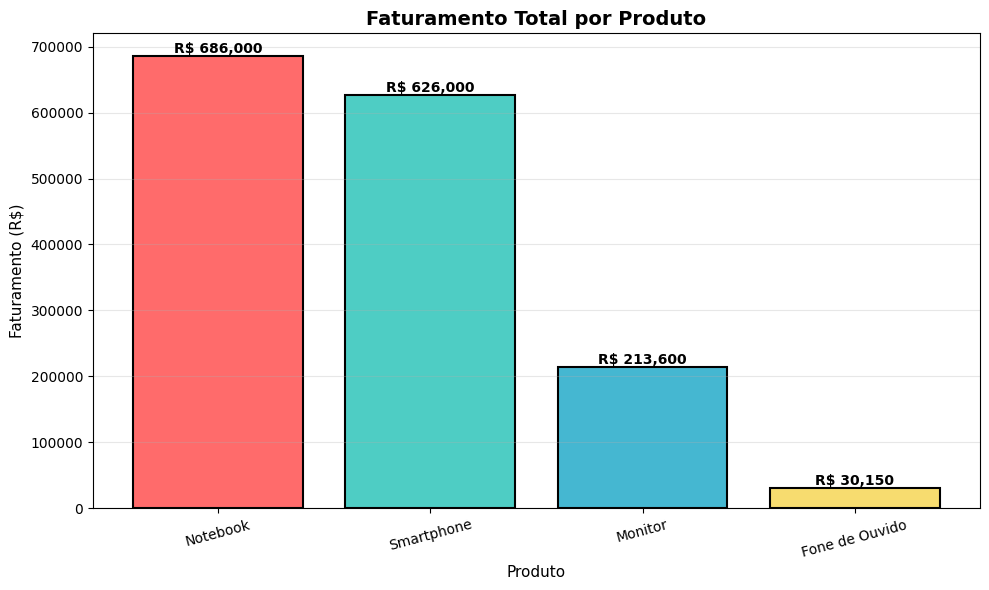

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
cores = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#F7DC6F']
barras = ax.bar(faturamento_por_produto.index, faturamento_por_produto.values, color=cores, edgecolor='black', linewidth=1.5)

ax.set_title('Faturamento Total por Produto', fontsize=14, fontweight='bold')
ax.set_xlabel('Produto', fontsize=11)
ax.set_ylabel('Faturamento (R$)', fontsize=11)
ax.grid(axis='y', alpha=0.3)

for barra in barras:
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2., altura,
            f'R$ {altura:,.0f}',
            ha='center', va='bottom', fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Tarefa 2: Evolução das Vendas ao Longo do Tempo

In [5]:
df['Mes'] = df['Data'].dt.to_period('M')

print("Coluna Mes criada!")
print(df[['Data', 'Mes']].head(10))

Coluna Mes criada!
        Data      Mes
0 2024-04-12  2024-04
1 2024-06-28  2024-06
2 2024-04-02  2024-04
3 2024-01-15  2024-01
4 2024-04-16  2024-04
5 2024-03-12  2024-03
6 2024-01-21  2024-01
7 2024-04-12  2024-04
8 2024-05-01  2024-05
9 2024-03-15  2024-03


In [6]:
vendas_por_mes = df.groupby('Mes')['Faturamento_Total'].sum()

print("Faturamento por Mês:")
print(vendas_por_mes)
print(f"\nMês com maior faturamento: {vendas_por_mes.idxmax()} (R$ {vendas_por_mes.max():,.2f})")
print(f"Mês com menor faturamento: {vendas_por_mes.idxmin()} (R$ {vendas_por_mes.min():,.2f})")

Faturamento por Mês:
Mes
2024-01    210300
2024-02    235950
2024-03    278450
2024-04    247650
2024-05    379650
2024-06    203750
Freq: M, Name: Faturamento_Total, dtype: int64

Mês com maior faturamento: 2024-05 (R$ 379,650.00)
Mês com menor faturamento: 2024-06 (R$ 203,750.00)


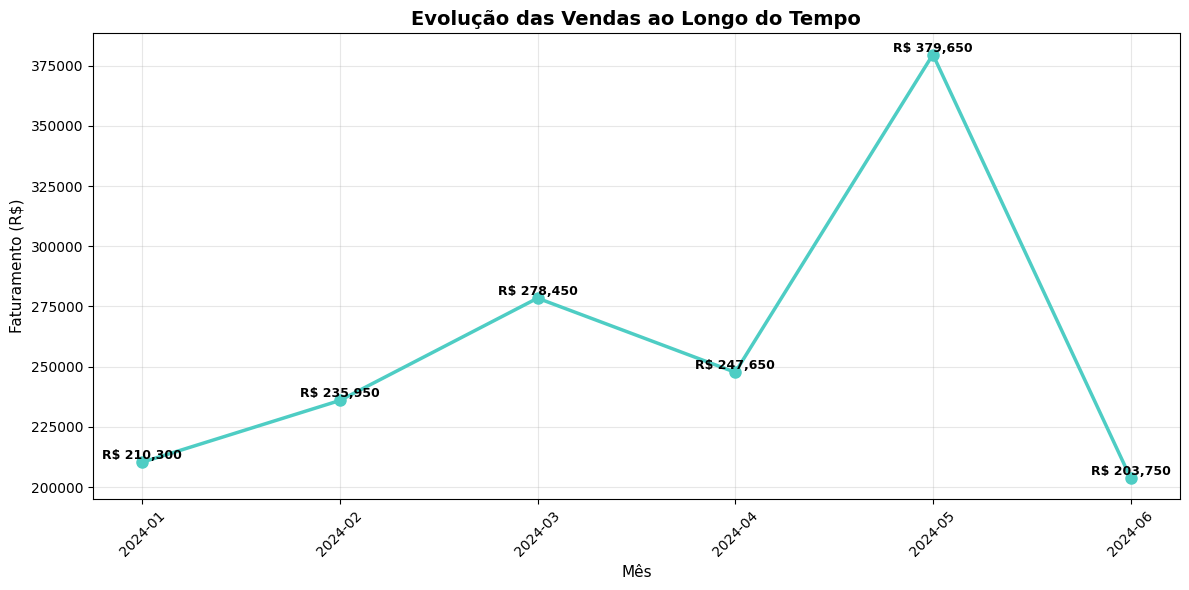

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
meses_str = [str(mes) for mes in vendas_por_mes.index]
ax.plot(meses_str, vendas_por_mes.values, marker='o', linewidth=2.5, markersize=8, color='#4ECDC4')

ax.set_title('Evolução das Vendas ao Longo do Tempo', fontsize=14, fontweight='bold')
ax.set_xlabel('Mês', fontsize=11)
ax.set_ylabel('Faturamento (R$)', fontsize=11)
ax.grid(True, alpha=0.3)

for i, (mes, valor) in enumerate(zip(meses_str, vendas_por_mes.values)):
    ax.text(i, valor, f'R$ {valor:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Tarefa 3: Distribuição da Quantidade Vendida

In [8]:
quantidade_por_produto = df.groupby('Produto')['Quantidade'].sum()

print("Quantidade Total de Itens Vendidos por Produto:")
print(quantidade_por_produto)
print(f"\nTotal de itens vendidos: {quantidade_por_produto.sum()}")

Quantidade Total de Itens Vendidos por Produto:
Produto
Fone de Ouvido    201
Monitor           178
Notebook          196
Smartphone        313
Name: Quantidade, dtype: int64

Total de itens vendidos: 888


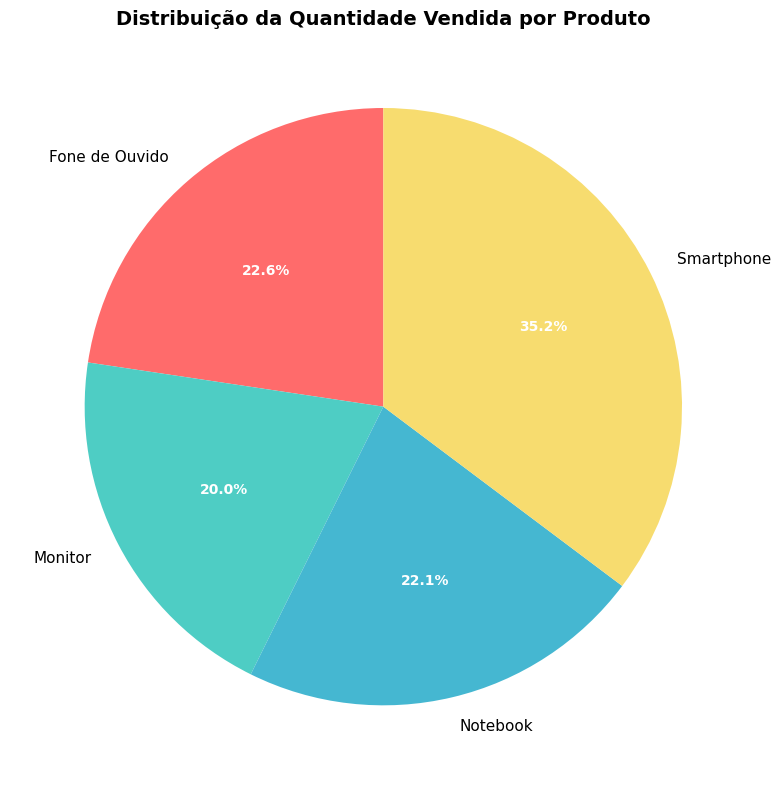

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
cores = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#F7DC6F']
wedges, texts, autotexts = ax.pie(
    quantidade_por_produto.values,
    labels=quantidade_por_produto.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=cores,
    textprops={'fontsize': 11}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Distribuição da Quantidade Vendida por Produto', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Resumo Executivo

In [10]:
print("\n" + "="*70)
print("RESUMO EXECUTIVO - ANÁLISE DE VENDAS")
print("="*70)

print(f"\n📊 FATURAMENTO POR PRODUTO:")
for produto, valor in faturamento_por_produto.items():
    percentual = (valor / faturamento_por_produto.sum()) * 100
    print(f"  {produto}: R$ {valor:,.2f} ({percentual:.1f}%)")

print(f"\n📈 EVOLUÇÃO MENSAL:")
print(f"  Maior faturamento: {vendas_por_mes.idxmax()} com R$ {vendas_por_mes.max():,.2f}")
print(f"  Menor faturamento: {vendas_por_mes.idxmin()} com R$ {vendas_por_mes.min():,.2f}")
print(f"  Crescimento/Queda máxima mês a mês: {(vendas_por_mes.diff().max()):,.2f}")

print(f"\n📦 QUANTIDADE VENDIDA:")
for produto, qtd in quantidade_por_produto.items():
    percentual = (qtd / quantidade_por_produto.sum()) * 100
    print(f"  {produto}: {qtd} unidades ({percentual:.1f}%)")

print(f"\n💰 TOTAIS:")
print(f"  Faturamento Total: R$ {faturamento_por_produto.sum():,.2f}")
print(f"  Total de Unidades Vendidas: {quantidade_por_produto.sum()}")
print(f"  Preço Médio por Unidade: R$ {faturamento_por_produto.sum() / quantidade_por_produto.sum():,.2f}")

print("\n" + "="*70)


RESUMO EXECUTIVO - ANÁLISE DE VENDAS

📊 FATURAMENTO POR PRODUTO:
  Notebook: R$ 686,000.00 (44.1%)
  Smartphone: R$ 626,000.00 (40.2%)
  Monitor: R$ 213,600.00 (13.7%)
  Fone de Ouvido: R$ 30,150.00 (1.9%)

📈 EVOLUÇÃO MENSAL:
  Maior faturamento: 2024-05 com R$ 379,650.00
  Menor faturamento: 2024-06 com R$ 203,750.00
  Crescimento/Queda máxima mês a mês: 132,000.00

📦 QUANTIDADE VENDIDA:
  Fone de Ouvido: 201 unidades (22.6%)
  Monitor: 178 unidades (20.0%)
  Notebook: 196 unidades (22.1%)
  Smartphone: 313 unidades (35.2%)

💰 TOTAIS:
  Faturamento Total: R$ 1,555,750.00
  Total de Unidades Vendidas: 888
  Preço Médio por Unidade: R$ 1,751.97

